In [8]:
# Multiple Linear Regression (Advertising dataset)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
# Step 1: Load dataset
# Dataset should have columns: "TV", "Radio", "Newspaper", "Sales"
dataset = pd.read_csv("Advertising.csv")
dataset

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [10]:
# Step 2: Separate features (X) and target (y) in an easy way
X = dataset[["TV", "Radio", "Newspaper"]].values   # 3 features
y = dataset["Sales"].values                        # target

In [11]:

# Step 3: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=0
)
print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

Shapes -> X_train: (133, 3) X_test: (67, 3)


In [12]:
# Step 4: Train the model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Step 5: Predict on the test set
y_pred = regressor.predict(X_test)

In [14]:
# Step 6: Print coefficients and intercept
print("Intercept:", regressor.intercept_)
print("Coefficients (slopes for TV, Radio, Newspaper):", regressor.coef_)

Intercept: 2.903764504319204
Coefficients (slopes for TV, Radio, Newspaper): [0.0443459  0.19660591 0.00262562]


In [15]:
# Step 7: Evaluate performance
print("MSE on test set:", mean_squared_error(y_test, y_pred))
print("R^2 on test set:", r2_score(y_test, y_pred))

MSE on test set: 3.386478605495981
R^2 on test set: 0.8710873114733414


In [16]:
# Step 8: Single prediction example
# Example: predict sales for TV=200, Radio=30, Newspaper=50
single_pred = regressor.predict([[200, 30, 50]])
print("Predicted Sales for TV=200, Radio=30, Newspaper=50:", single_pred[0])

Predicted Sales for TV=200, Radio=30, Newspaper=50: 17.802402163902965


In [17]:
# Step 9: Manual calculation using learned params
manual_pred = (regressor.intercept_
               + regressor.coef_[0]*200   # TV coefficient × TV spend
               + regressor.coef_[1]*30    # Radio coefficient × Radio spend
               + regressor.coef_[2]*50)   # Newspaper coefficient × Newspaper spend
print("Manual prediction (same input):", manual_pred)

Manual prediction (same input): 17.802402163902965


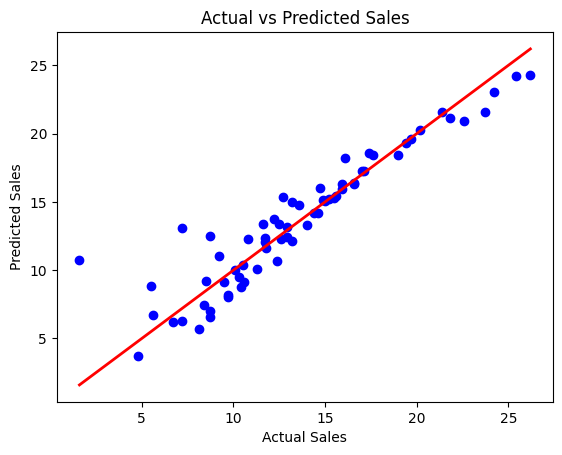

In [18]:

# Step 10: Visualization (only possible in 2D or 3D)
# We cannot plot all 3 features against sales directly in one 2D graph.
# Instead, we can plot actual vs predicted sales.
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()